<a href="https://colab.research.google.com/github/m-manuelmussa/Drug-Repurposing-IPEs-MtrD-Pharmacophores-Molecular-Docking-Dynamics/blob/main/3_C%C3%A1lculo_e_An%C3%A1lise_de_Similaridade_Estrutural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cálculo e Análise de Similaridade Estrutural**
**Objectivo**: Calcular a similaridade de tanimoto e analisar visualmente a estrutura de hits e os de referência


***Autor: Micliete Lopes Manuel Mussa***


## **1. Instalação de Dependências**

In [37]:
!pip install rdkit pandas

## **2. Importação de bibliotecas**

In [2]:
import pandas as pd
from IPython.display import display
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem import Draw

## **3. Leitura do dataset curado**

In [3]:
# 1. Carrega DIRETO do CSV
input_file = "medicamentos_aprovados_chembl_curadoria_quimica.csv"
df_quimico = pd.read_csv(input_file)

print(f"Total de fármacos curados carregados do CSV: {len(df_quimico)}")

Total de fármacos curados carregados do CSV: 2341


## **4. Input de SMILES de EPIs de referência**

In [38]:
# 2. Definição dos SMILES do EPI de referência
epis_raw = [
    {"nome": "NMP",      "smiles": "C1CN(CCN1)CC2=CC=CC3=CC=CC=C32"},
]

## **5. Cálculo de Fingerprints de EPIs de referência**

In [39]:
# 3. Geração direta de Fingerprints (ECFP4, 2048 bits)
epis_curated = []
for epi in epis_raw:
    mol = Chem.MolFromSmiles(epi["smiles"])
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    epis_curated.append({
        "nome": epi["nome"],
        "smiles": epi["smiles"],
        "fp": fp
    })

[19:49:22] DEPRECATION WARNING: please use MorganGenerator


In [40]:
# 4. Reconstrução dos Fingerprints do Dataset Completo
dataset_fps = []
for idx, row in df_quimico.iterrows():
    if 'morgan_fp' in df_quimico.columns and isinstance(row['morgan_fp'], str) and len(row['morgan_fp']) == 2048:
        fp = DataStructs.CreateFromBitString(row['morgan_fp'])
    else:
        mol = Chem.MolFromSmiles(row['smiles_curado'])
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
    dataset_fps.append(fp)

## **5. Cálculo da Similaridade de Tanimoto**

In [41]:
# 5. Cálculo do Tanimoto para todo o dataset
for epi in epis_curated:
    col_name = f"tanimoto_{epi['nome'].lower().replace('-', '_')}"
    df_quimico[col_name] = [DataStructs.TanimotoSimilarity(epi["fp"], fp_target) for fp_target in dataset_fps]

## **6. Selecção de Top 10 Hits**

In [42]:
# Dicionário para armazenar os DataFrames individualizados
dataframes_individuais = {}

# Percorre cada EPI presente em epis_curated
for epi in epis_curated:
    nome_epi = epi["nome"]
    smiles_epi = epi["smiles"]
    col_tanimoto = f"tanimoto_{nome_epi.lower().replace('-', '_')}"

    # 1. Filtra os Top 10 Hits do dataset ordenados pelo Tanimoto do EPI atual
    df_top10 = df_quimico.sort_values(by=col_tanimoto, ascending=False).head(10).copy()

    # 2. Constrói o DataFrame individual do EPI
    df_rank_epi = pd.DataFrame({
        "EPI_Referencia": nome_epi,
        "Ranking": range(1, len(df_top10) + 1),
        "ChEMBL_ID": df_top10["chembl_id"],
        "Nome_Hit": df_top10["nome_preferencial"],
        "SMILES_Curado": df_top10["smiles_curado"],
        "Similaridade_Tanimoto": df_top10[col_tanimoto]
    })

    # Armazena o DataFrame individual no dicionário
    dataframes_individuais[nome_epi] = df_rank_epi

In [43]:
# Acessando o DataFrame do NMP
df_nmp = dataframes_individuais["NMP"]
display(df_nmp)

,EPI_Referencia,Ranking,ChEMBL_ID,Nome_Hit,SMILES_Curado,Similaridade_Tanimoto
448,NMP,1,CHEMBL761,NAPHAZOLINE,c1ccc2c(CC3=NCCN3)cccc2c1,0.428571
1010,NMP,2,CHEMBL203266,TRIMETAZIDINE,COc1ccc(CN2CCNCC2)c(OC)c1OC,0.418605
282,NMP,3,CHEMBL18442,PLERIXAFOR,c1cc(CN2CCCNCCNCCCNCC2)ccc1CN1CCCNCCNCCCNCC1,0.410256
321,NMP,4,CHEMBL626,NAFTIFINE,CN(C/C=C/c1ccccc1)Cc1cccc2ccccc12,0.312500
671,NMP,5,CHEMBL990,BUTENAFINE,CN(Cc1ccc(C(C)(C)C)cc1)Cc1cccc2ccccc12,0.312500
243,NMP,6,CHEMBL276520,INDALPINE,c1ccc2c(CCC3CCNCC3)c[nH]c2c1,0.291667
506,NMP,7,CHEMBL822,TERBINAFINE,CN(C/C=C/C#CC(C)(C)C)Cc1cccc2ccccc12,0.283019
514,NMP,8,CHEMBL833,TICLOPIDINE,Clc1ccccc1CN1CCc2sccc2C1,0.280000
884,NMP,9,CHEMBL142635,NAFTOPIDIL,COc1ccccc1N1CCN(CC(O)COc2cccc3ccccc23)CC1,0.275862
1993,NMP,10,CHEMBL2104993,VORTIOXETINE,Cc1ccc(Sc2ccccc2N2CCNCC2)c(C)c1,0.250000


## **7. Draw Molecular: Referência vs Top 10 Hits**

In [44]:
def desenhar_hits_2d(nome_epi, df_rank_epi, epis_raw):
    """
    Desenha a estrutura de referência (buscada em epis_raw) e seus top 10 hits em 2D.
    """
    # 1. Resgata o SMILES do EPI de referência na lista
    smiles_ref = next(item["smiles"] for item in epis_raw if item["nome"] == nome_epi)

    # 2. Prepara a lista de moléculas e legendas
    mols = [Chem.MolFromSmiles(smiles_ref)]
    legendas = [f"REFERÊNCIA:\n{nome_epi}"]

    # 3. Adiciona as moléculas e scores do DataFrame
    for _, row in df_rank_epi.iterrows():
        mols.append(Chem.MolFromSmiles(row["SMILES_Curado"]))
        legendas.append(f"#{row['Ranking']} {row['Nome_Hit']}\nTanimoto: {row['Similaridade_Tanimoto']:.4f}")

    # 4. Gera a grade de imagens (useSVG=False força o retorno em formato PIL/PNG)
    img_grid = Draw.MolsToGridImage(
        mols,
        molsPerRow=4,
        subImgSize=(280, 230),
        legends=legendas,
        useSVG=False
    )

    filename = f"grade_hits_{nome_epi.lower().replace('-', '_')}.png"

    # 5. Salva a imagem checando o tipo retornado pelo RDKit
    if hasattr(img_grid, 'save'):
        img_grid.save(filename)
    elif hasattr(img_grid, 'data'):
        # Se retornar um objeto IPython.display.Image
        with open(filename, 'wb') as f:
            f.write(img_grid.data)

    return img_grid

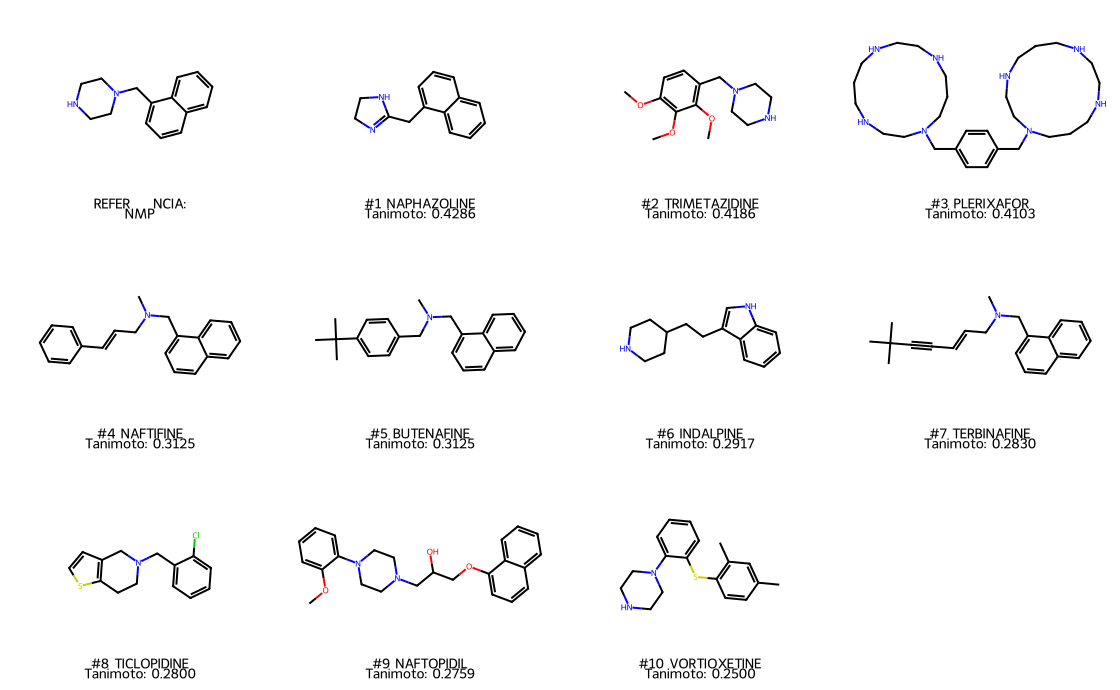

In [45]:
img_nmp = desenhar_hits_2d("NMP", dataframes_individuais["NMP"], epis_curated)
display(img_nmp)

## **8. Exportação do Dataset dos Top 10 Hits análogos do NMP**

In [46]:
# 1. Seleciona o DataFrame do NMP a partir do dicionário
df_nmp = dataframes_individuais["NMP"]

# 2. Salva em arquivo CSV
nome_arquivo = "top10_hits_nmp.csv"
df_nmp.to_csv(nome_arquivo, index=False, encoding='utf-8-sig')

print(f"CSV dos Top 10 hits do NMP salvo com sucesso em: {nome_arquivo}")

CSV dos Top 10 hits do NMP salvo com sucesso em: top10_hits_nmp.csv


***Autor: Micliete Lopes Manuel Mussa, Farmacêutico.***